In [1]:
import pandas as pd


In [2]:
#load the dataset and view 
dataset = pd.read_csv('insurance.csv')

In [5]:
dataset

,age,sex,bmi,children,smoker,region,medicalCost
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [19]:
# this code is to keep an original copy of my dat in case i want to reverse any transformations.

original_dataset = dataset.copy()

In [20]:
dataset.head()

,age,sex,bmi,children,smoker,region,medicalCost
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
# This code checks the data types in each colums

print (dataset.dtypes)

age              int64
sex             object
bmi            float64
children         int64
smoker          object
region          object
medicalCost    float64
dtype: object


In [22]:
# this code checks for the missing values in the dataset

print (dataset.isnull().sum())

age            0
sex            0
bmi            0
children       0
smoker         0
region         0
medicalCost    0
dtype: int64


In [23]:
# this code is to check the dataset for any duplicated entries 

dataset = dataset.drop_duplicates()

In [24]:
# This code will summarize the all the individual statistical 
# values of the numerical columns 

print (dataset.describe ())

               age          bmi     children   medicalCost
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


In [25]:
# the range of all the numerical values are too wide, so we may need to transform the data by normalization or standardization.
# that way, we can either strethch the numbers to fit between o and 1 or we adjust the numbers to weigh the same thing.

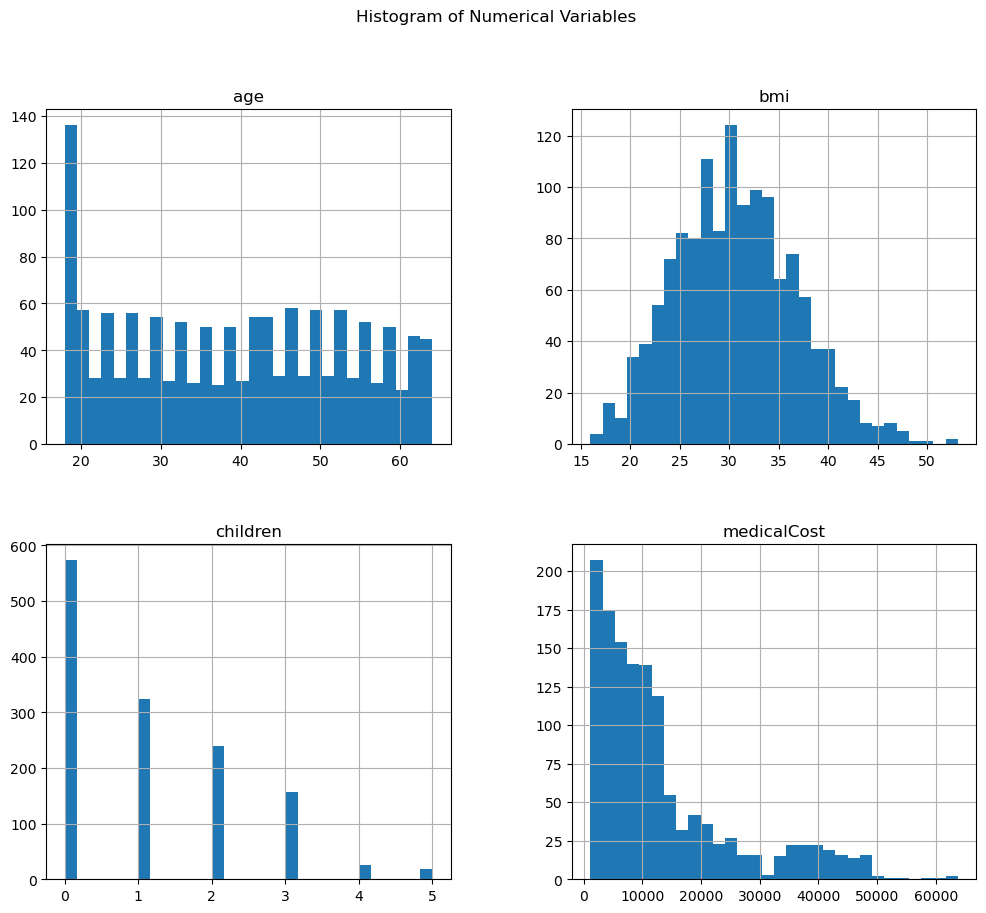

In [30]:
# we are plotting histograms to visualize the distribution of all
# the numeric variables across the data to help us check for all the 
# characteristics that may stand out in the data.

import matplotlib.pyplot as plt

dataset.hist(bins=30, figsize=(12, 10))
plt.suptitle ('Histogram of Numerical Variables')
plt.show()


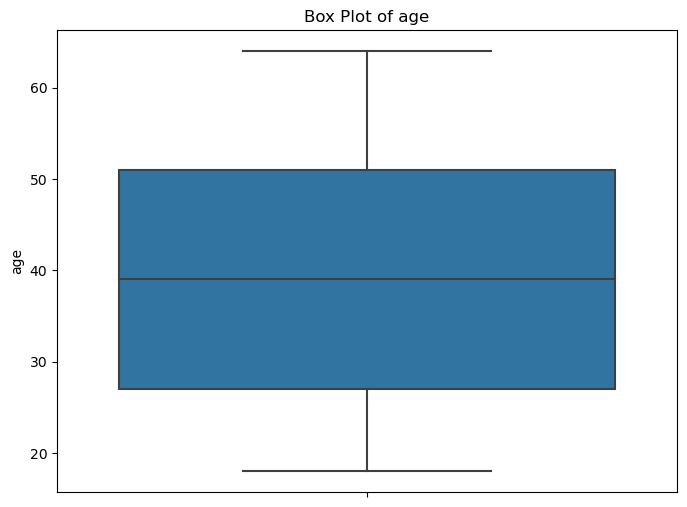

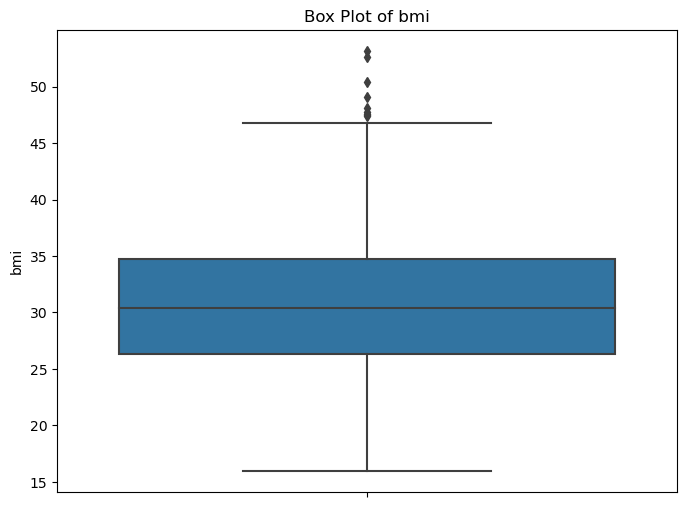

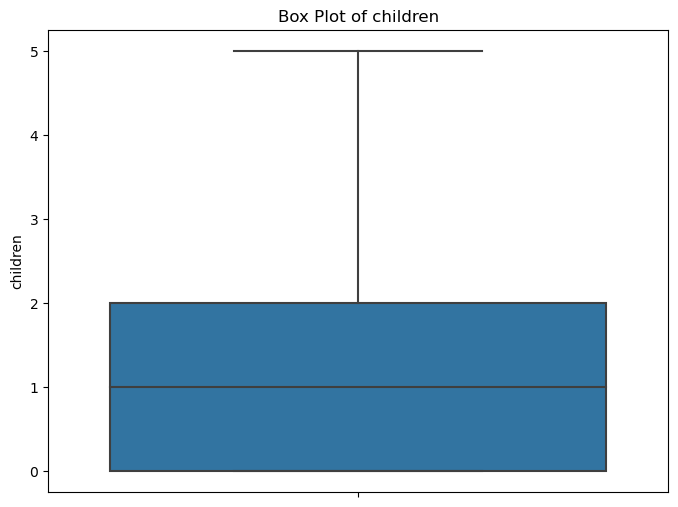

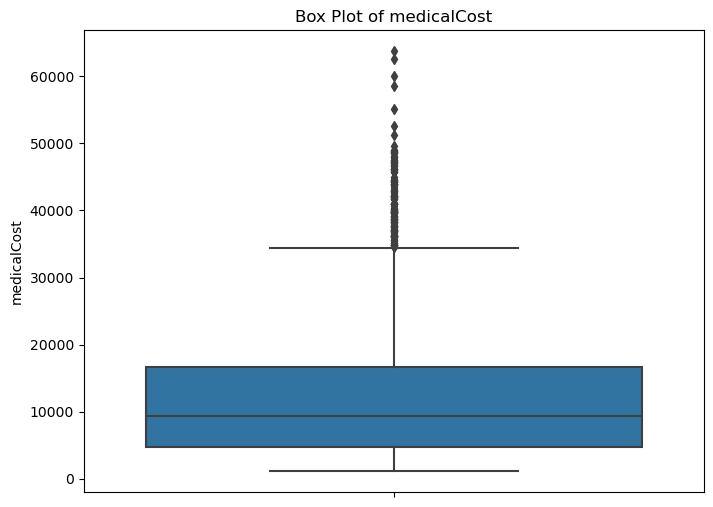

In [32]:
# this code will help to detect any outliers in the numerical dataset.

# first i selected all the numerical columns in the dataset identified by 
# their data type

import seaborn as sns

numerical_columns = dataset.select_dtypes(include=['float64', 'int64']).columns

# Then i used a loop to individually go through numerical columns
# and create box plots for all the variables.

for column in numerical_columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=dataset[column])
    plt.title(f'Box Plot of {column}')
    plt.show()


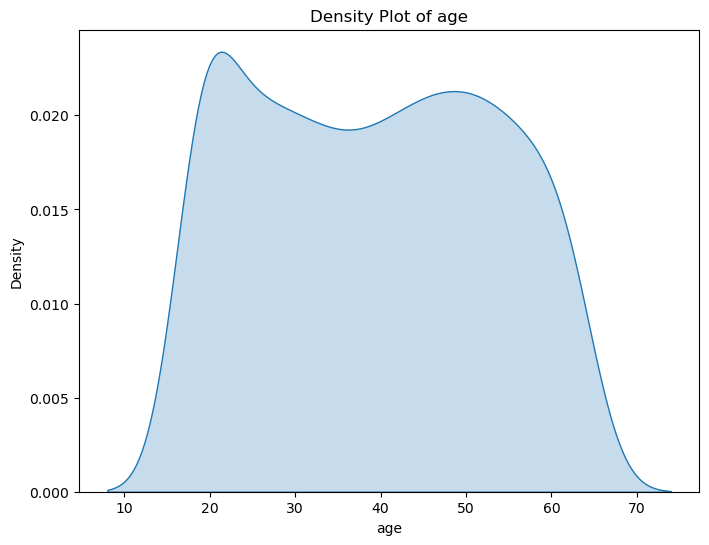

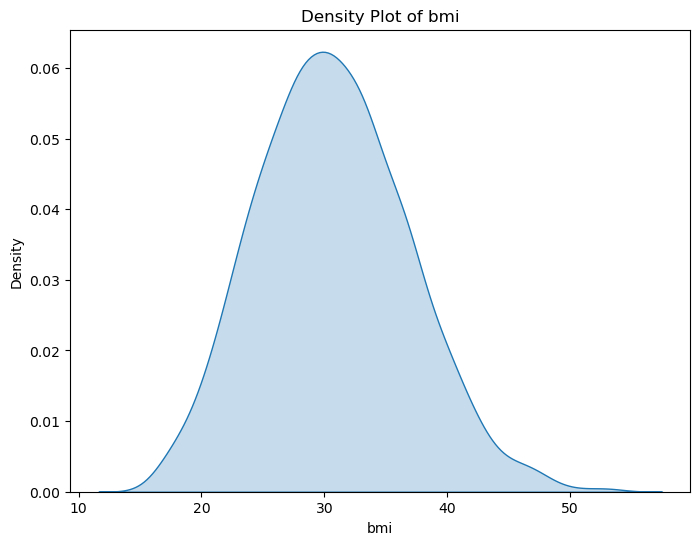

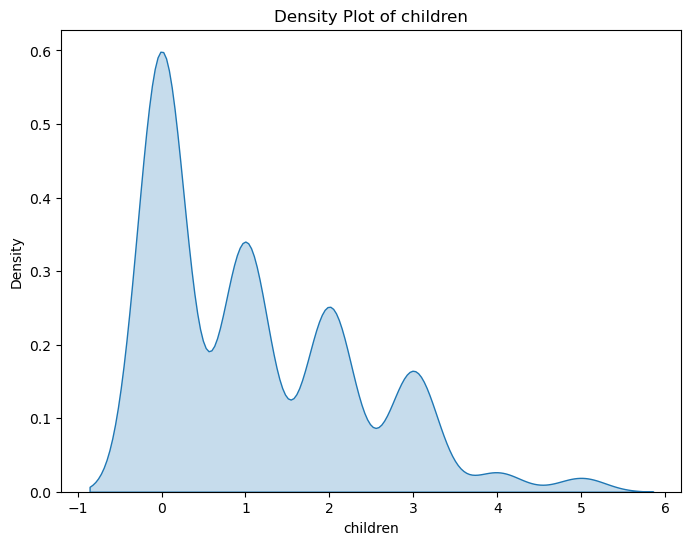

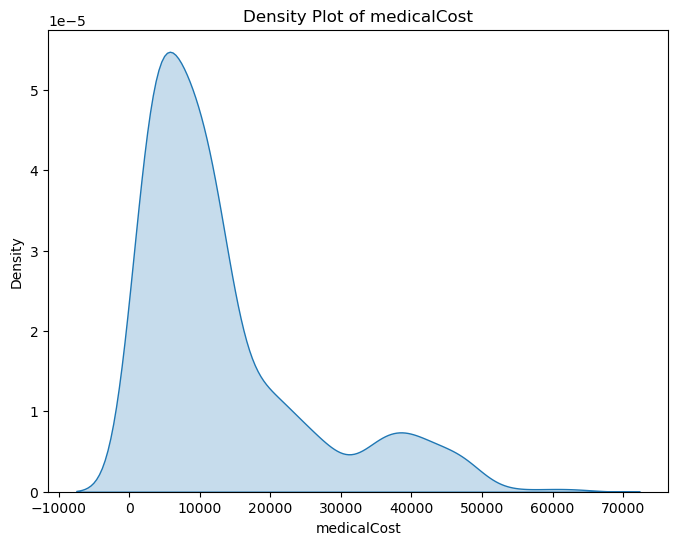

In [33]:
# this code will hsow a density plot for this data set numercial variables.
# this will allow the distribution to be easier to see 


for column in dataset.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8, 6))
    sns.kdeplot(dataset[column], fill=True)
    plt.title(f'Density Plot of {column}')
    plt.show()


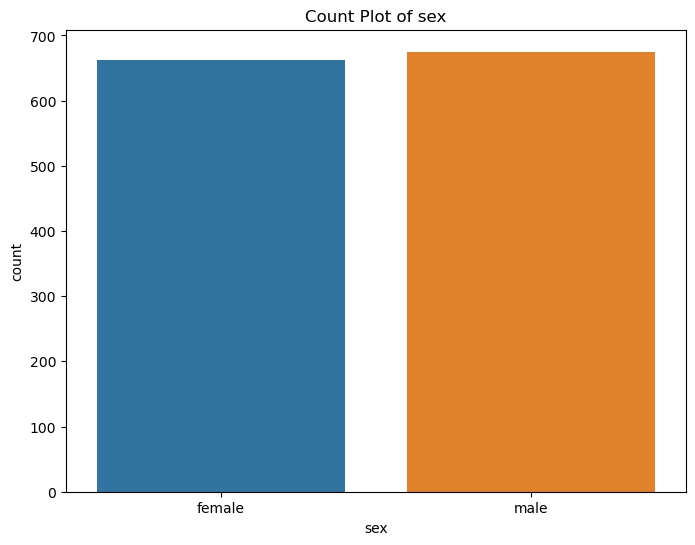

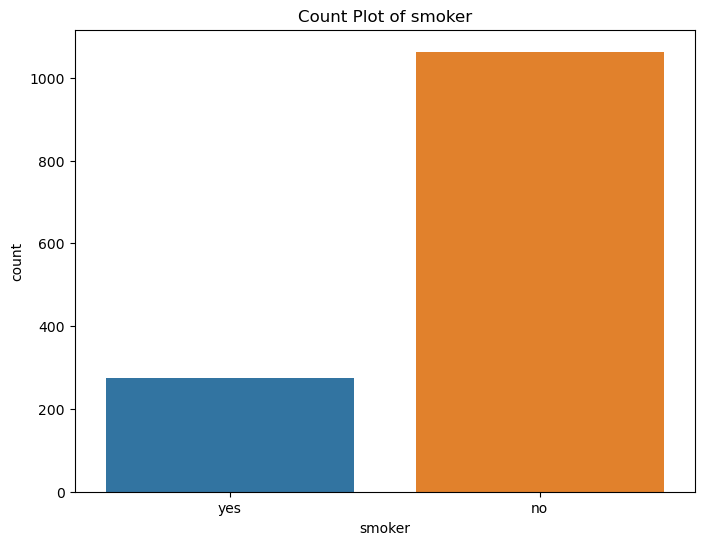

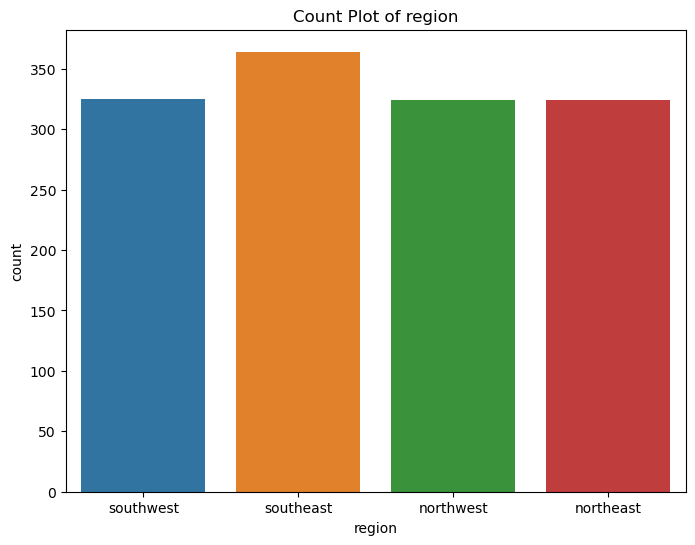

In [34]:
# this code will show the frequency of each category in the non numerical variables.

categorical_columns = dataset.select_dtypes(include=['object']).columns

for column in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(x=dataset[column])
    plt.title(f'Count Plot of {column}')
    plt.show()


In [35]:
# this code will standardize the numerical data to ensure all the means are 0 and the standard deviations are 1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset[['age', 'bmi', 'children', 'medicalCost']] = scaler.fit_transform(dataset[['age', 'bmi', 'children','medicalCost']])

print (dataset.head())

        age     sex       bmi  children smoker     region  medicalCost
0 -1.440418  female -0.453160 -0.909234    yes  southwest     0.297857
1 -1.511647    male  0.509422 -0.079442     no  southeast    -0.954381
2 -0.799350    male  0.383155  1.580143     no  southeast    -0.729373
3 -0.443201    male -1.305052 -0.909234     no  northwest     0.719104
4 -0.514431    male -0.292456 -0.909234     no  northwest    -0.777499


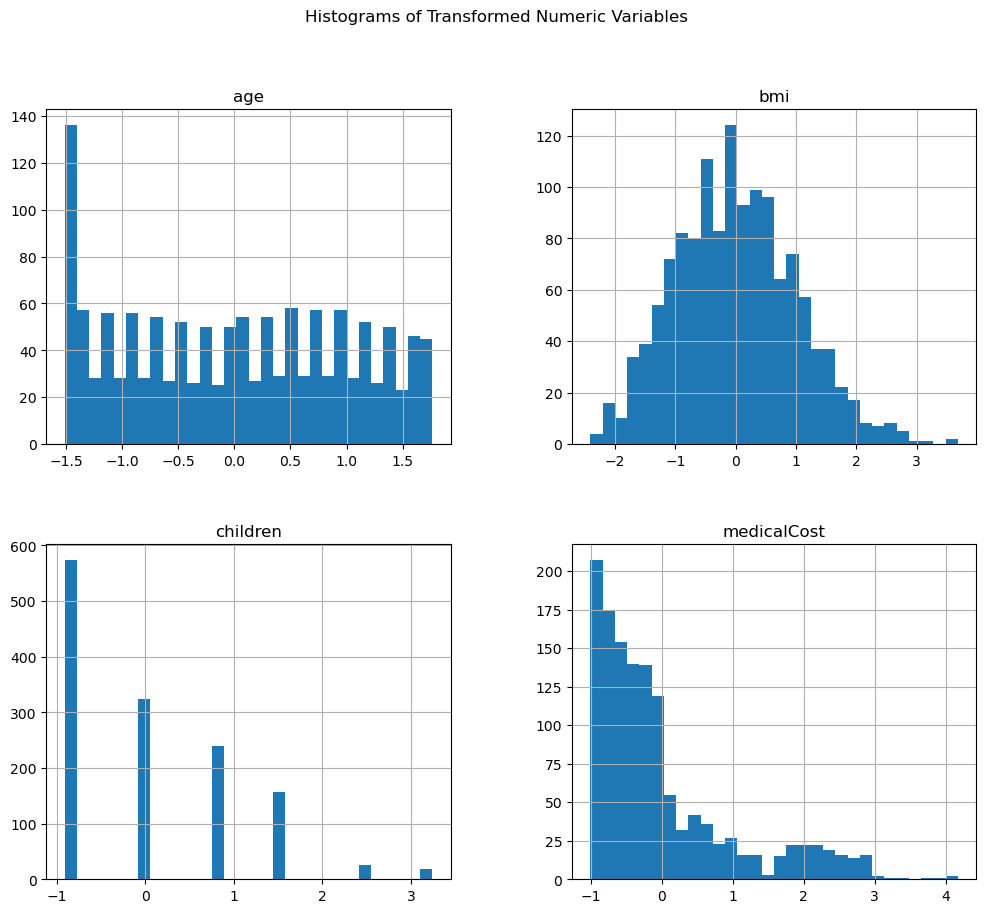

In [36]:
# this code will visualize the dataset after the standardization has been done

# this will plot histograms for the transformed data
dataset.hist(bins=30, figsize=(12, 10))
plt.suptitle('Histograms of Transformed Numeric Variables')
plt.show()


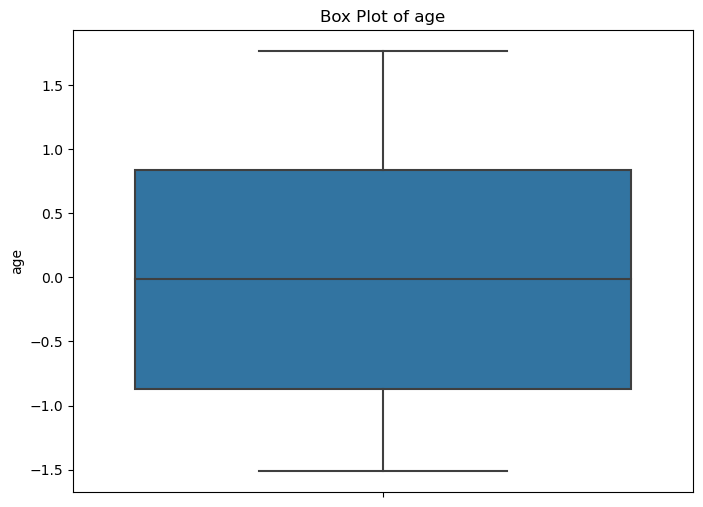

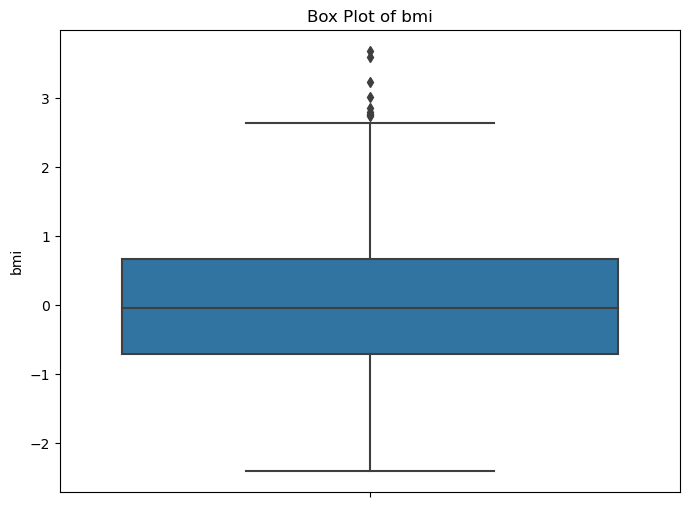

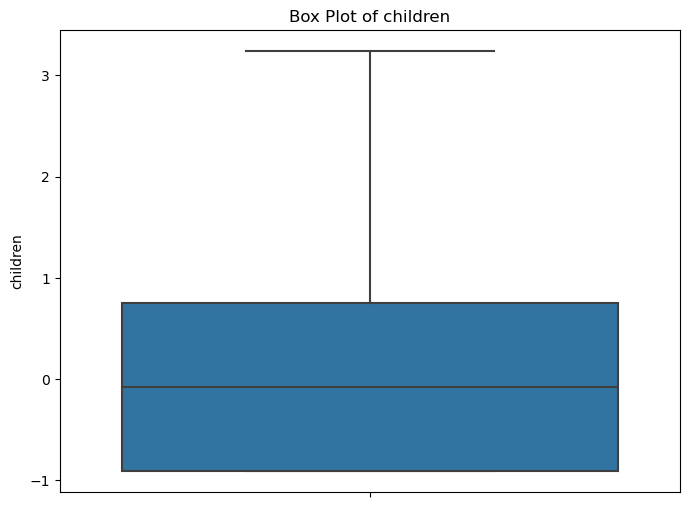

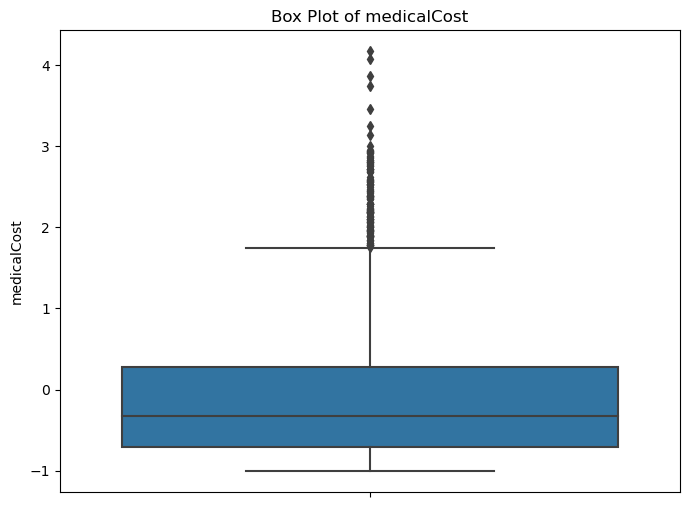

In [37]:
# this code will visualize the dataset after the standardization has been done

# this will plot box plots for the transformed data
# first i selected all the numerical columns in the dataset identified by 
# their data type

numerical_columns_transformed = dataset.select_dtypes(include=['float64', 'int64']).columns

# Then i used a loop to individually go through numerical columns
# and create box plots for all the variables.

for column in numerical_columns_transformed:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=dataset[column])
    plt.title(f'Box Plot of {column}')
    plt.show()




In [38]:
# this code will convert variables to numeric through one-hot-encoding

dataset_encoded = pd.get_dummies(dataset, columns = ['sex', 'smoker', 'region'], drop_first =True)

print (dataset_encoded.head())

        age       bmi  children  medicalCost  sex_male  smoker_yes  \
0 -1.440418 -0.453160 -0.909234     0.297857         0           1   
1 -1.511647  0.509422 -0.079442    -0.954381         1           0   
2 -0.799350  0.383155  1.580143    -0.729373         1           0   
3 -0.443201 -1.305052 -0.909234     0.719104         1           0   
4 -0.514431 -0.292456 -0.909234    -0.777499         1           0   

   region_northwest  region_southeast  region_southwest  
0                 0                 0                 1  
1                 0                 1                 0  
2                 0                 1                 0  
3                 1                 0                 0  
4                 1                 0                 0  


In [39]:
# after encoding i noticed it had dropped the first category of each variable, so i am now  
# applying the one-hot encoding with drop_first=False
dataset_encoded_all = pd.get_dummies(dataset, columns=['sex', 'smoker', 'region'], drop_first=False)

# Display the encoded dataset with all categories
print(dataset_encoded_all.head())


        age       bmi  children  medicalCost  sex_female  sex_male  smoker_no  \
0 -1.440418 -0.453160 -0.909234     0.297857           1         0          0   
1 -1.511647  0.509422 -0.079442    -0.954381           0         1          1   
2 -0.799350  0.383155  1.580143    -0.729373           0         1          1   
3 -0.443201 -1.305052 -0.909234     0.719104           0         1          1   
4 -0.514431 -0.292456 -0.909234    -0.777499           0         1          1   

   smoker_yes  region_northeast  region_northwest  region_southeast  \
0           1                 0                 0                 0   
1           0                 0                 0                 1   
2           0                 0                 0                 1   
3           0                 0                 1                 0   
4           0                 0                 1                 0   

   region_southwest  
0                 1  
1                 0  
2                 0 

In [40]:
# i noticed that there are some features that might capture more information if i generated new synced features and decided to do that. 

# this code will create an interaction bnetwenn BMI and smoker status


dataset_encoded_all['bmi_smoker_interaction'] = dataset_encoded_all['bmi'] * dataset_encoded_all['smoker_yes']

print (dataset_encoded_all)


           age       bmi  children  medicalCost  sex_female  sex_male  \
0    -1.440418 -0.453160 -0.909234     0.297857           1         0   
1    -1.511647  0.509422 -0.079442    -0.954381           0         1   
2    -0.799350  0.383155  1.580143    -0.729373           0         1   
3    -0.443201 -1.305052 -0.909234     0.719104           0         1   
4    -0.514431 -0.292456 -0.909234    -0.777499           0         1   
...        ...       ...       ...          ...         ...       ...   
1333  0.767704  0.050269  1.580143    -0.221263           0         1   
1334 -1.511647  0.206053 -0.909234    -0.914695           1         0   
1335 -1.511647  1.014490 -0.909234    -0.962287           1         0   
1336 -1.297958 -0.797524 -0.909234    -0.931054           1         0   
1337  1.551231 -0.261299 -0.909234     1.310298           1         0   

      smoker_no  smoker_yes  region_northeast  region_northwest  \
0             0           1                 0           

In [54]:
# i want to create an interaction terms for each of the 
# predictors in the data 

predictors = ['age', 'bmi', 'children', 'smoker_yes']

# this code will loop through each pair of predictors to create interaction terms
for i in range(len(predictors)):
    for j in range(i + 1, len(predictors)):
        interaction_term = f"{predictors[i]}_{predictors[j]}_interaction"
        dataset_encoded_all[interaction_term] = dataset_encoded_all[predictors[i]] * dataset_encoded_all[predictors[j]]

# Display the first few rows of the updated DataFrame
print(dataset_encoded_all.head())

        age       bmi  children  medicalCost  sex_female  sex_male  smoker_no  \
0 -1.440418 -0.453160 -0.909234     0.297857           1         0          0   
1 -1.511647  0.509422 -0.079442    -0.954381           0         1          1   
2 -0.799350  0.383155  1.580143    -0.729373           0         1          1   
3 -0.443201 -1.305052 -0.909234     0.719104           0         1          1   
4 -0.514431 -0.292456 -0.909234    -0.777499           0         1          1   

   smoker_yes  region_northeast  region_northwest  region_southeast  \
0           1                 0                 0                 0   
1           0                 0                 0                 1   
2           0                 0                 0                 1   
3           0                 0                 1                 0   
4           0                 0                 1                 0   

   region_southwest  bmi_smoker_interaction  age_bmi_interaction  \
0                 

In [55]:
print("Column names in the DataFrame:", dataset_encoded_all.columns)

print(dataset_encoded_all.head())

Column names in the DataFrame: Index(['age', 'bmi', 'children', 'medicalCost', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_smoker_interaction',
       'age_bmi_interaction', 'age_children_interaction',
       'age_smoker_yes_interaction', 'bmi_children_interaction',
       'bmi_smoker_yes_interaction', 'children_smoker_yes_interaction'],
      dtype='object')
        age       bmi  children  medicalCost  sex_female  sex_male  smoker_no  \
0 -1.440418 -0.453160 -0.909234     0.297857           1         0          0   
1 -1.511647  0.509422 -0.079442    -0.954381           0         1          1   
2 -0.799350  0.383155  1.580143    -0.729373           0         1          1   
3 -0.443201 -1.305052 -0.909234     0.719104           0         1          1   
4 -0.514431 -0.292456 -0.909234    -0.777499           0         1          1   

   smoker_yes  region_northeast  region_nor

In [56]:
print(dataset_encoded_all.columns)

print(dataset_encoded_all.dtypes)

Index(['age', 'bmi', 'children', 'medicalCost', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_smoker_interaction',
       'age_bmi_interaction', 'age_children_interaction',
       'age_smoker_yes_interaction', 'bmi_children_interaction',
       'bmi_smoker_yes_interaction', 'children_smoker_yes_interaction'],
      dtype='object')
age                                float64
bmi                                float64
children                           float64
medicalCost                        float64
sex_female                           uint8
sex_male                             uint8
smoker_no                            uint8
smoker_yes                           uint8
region_northeast                     uint8
region_northwest                     uint8
region_southeast                     uint8
region_southwest                     uint8
bmi_smoker_interaction             float64
ag

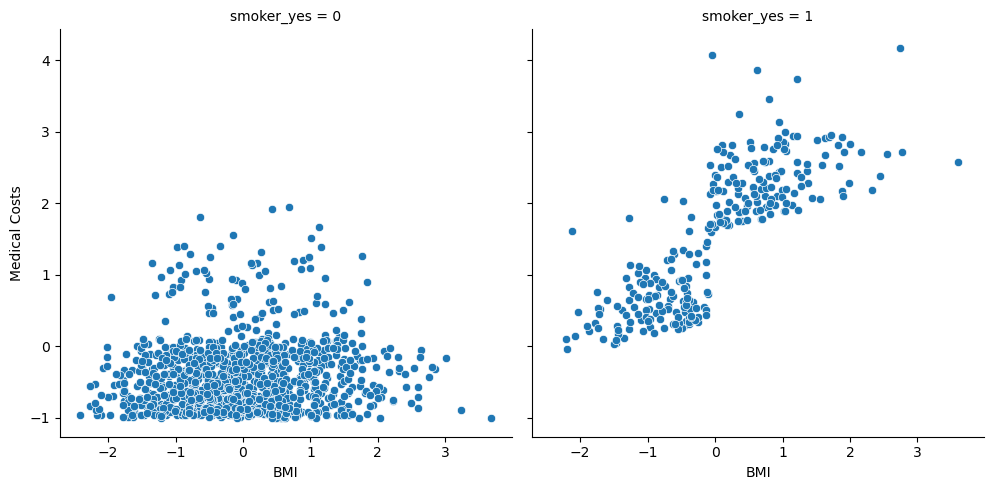

In [57]:
# now to visualize the relationship we have established between the 
# BMI and the medical costs for the people who smoke and the poeple who dont smoke 

# this will be visualized with a facet grid plot

g = sns.FacetGrid(dataset_encoded_all, col="smoker_yes", height=5, aspect=1)
g.map(sns.scatterplot, "bmi", "medicalCost")
g.add_legend()
g.set_axis_labels("BMI", "Medical Costs")
plt.show()

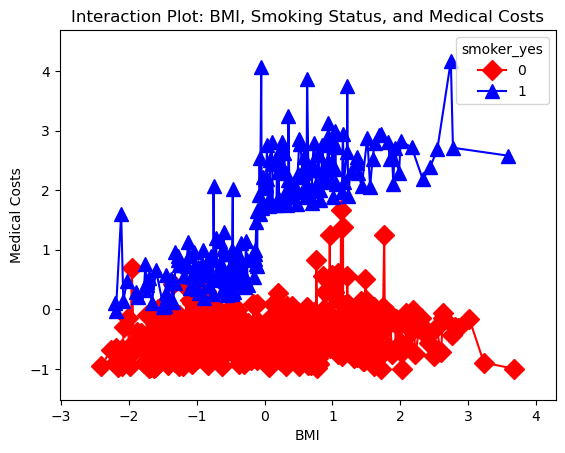

In [58]:
# now i am creating the interaction plot

import statsmodels.api as sm
from statsmodels.graphics.factorplots import interaction_plot

# Creating interaction plot
interaction_plot(dataset_encoded_all['bmi'], dataset_encoded_all['smoker_yes'], dataset_encoded_all['medicalCost'],
                 colors=['red', 'blue'], markers=['D', '^'], ms=10)
plt.xlabel('BMI')
plt.ylabel('Medical Costs')
plt.title('Interaction Plot: BMI, Smoking Status, and Medical Costs')
plt.show()


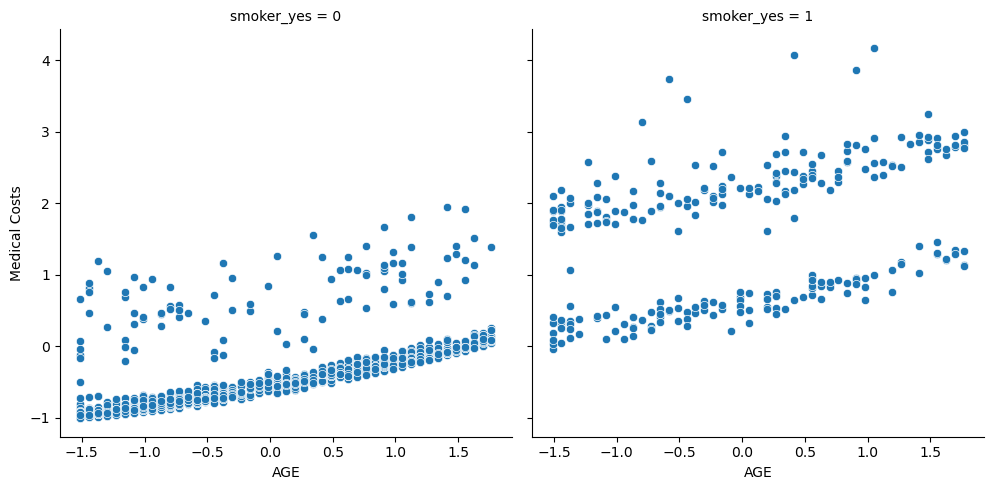

In [59]:
# now to visualize the relationship we have established between the 
# age and the medical costs for the people who smoke and the poeple who dont smoke 

# this will be visualized with a facet grid plot

g = sns.FacetGrid(dataset_encoded_all, col="smoker_yes", height=5, aspect=1)
g.map(sns.scatterplot, "age", "medicalCost")
g.add_legend()
g.set_axis_labels("AGE", "Medical Costs")
plt.show()

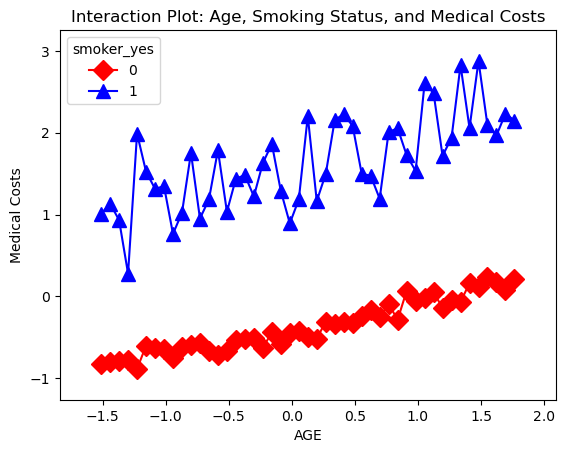

In [60]:
# now i am creating the interaction plot

import statsmodels.api as sm
from statsmodels.graphics.factorplots import interaction_plot

# Creating interaction plot
interaction_plot(dataset_encoded_all['age'], dataset_encoded_all['smoker_yes'], dataset_encoded_all['medicalCost'],
                 colors=['red', 'blue'], markers=['D', '^'], ms=10)
plt.xlabel('AGE')
plt.ylabel('Medical Costs')
plt.title('Interaction Plot: Age, Smoking Status, and Medical Costs')
plt.show()

In [66]:
# so after testing this out, i want to calculate the individual 
# correlations for each of the predictors 


# this code is to define the target variable
target = dataset_encoded['medicalCost']

# this code will list  all predictors including interaction terms
all_predictors = predictors + [col for col in dataset_encoded.columns if 'interaction' in col]

# this code will calculate and display the correlation for each predictor
for predictor in all_predictors:
    correlation = dataset_encoded[predictor].corr(target)
    print(f"Correlation between {predictor} and medicalCost: {correlation:.2f}")



Correlation between age and medicalCost: 0.30
Correlation between bmi and medicalCost: 0.20
Correlation between children and medicalCost: 0.07
Correlation between smoker_yes and medicalCost: 0.79


In [67]:
correlation_matrix = dataset_encoded.corr()

print (correlation_matrix)

                       age       bmi  children  medicalCost  sex_male  \
age               1.000000  0.109344  0.041536     0.298308 -0.019814   
bmi               0.109344  1.000000  0.012755     0.198401  0.046397   
children          0.041536  0.012755  1.000000     0.067389  0.017848   
medicalCost       0.298308  0.198401  0.067389     1.000000  0.058044   
sex_male         -0.019814  0.046397  0.017848     0.058044  1.000000   
smoker_yes       -0.025587  0.003746  0.007331     0.787234  0.076596   
region_northwest  0.001495 -0.136138  0.026044    -0.038695 -0.012482   
region_southeast -0.012311  0.270057 -0.023492     0.073578  0.017578   
region_southwest  0.009415 -0.006211  0.021538    -0.043637 -0.003767   

                  smoker_yes  region_northwest  region_southeast  \
age                -0.025587          0.001495         -0.012311   
bmi                 0.003746         -0.136138          0.270057   
children            0.007331          0.026044         -0.023492 

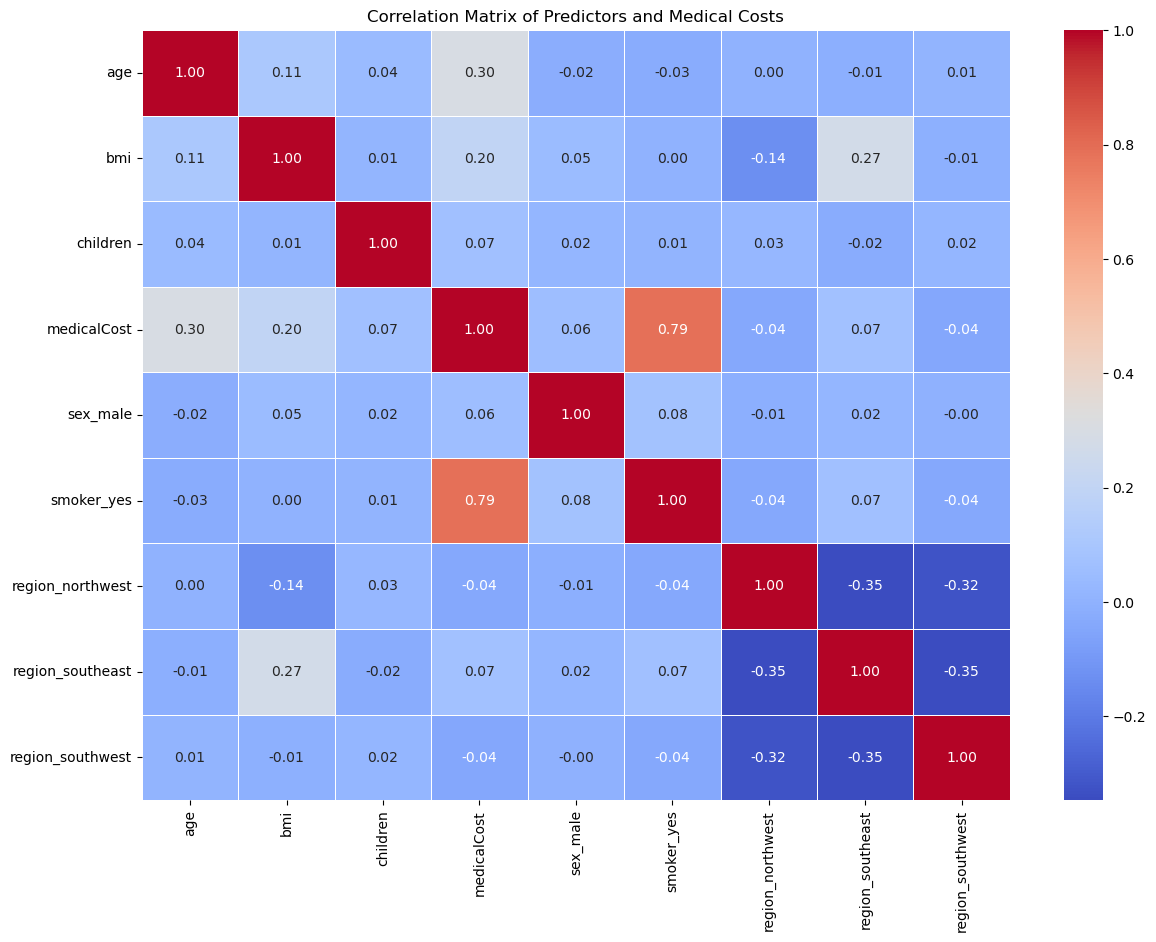

In [68]:
import seaborn as sns 
import matplotlib.pyplot as plt 

# this code will now plot the heatmap

plt.figure(figsize = (14,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Predictors and Medical Costs')
plt.show()

In [69]:
# now we are going to choose the top three predictors 

# i will start by extracting the correlation values with the target variable `medicalCost`
correlations_with_target = correlation_matrix['medicalCost']

# then i will sort predictors by the absolute value of their correlation with `medicalCost`
sorted_correlations = correlations_with_target.abs().sort_values(ascending=False)

# then finally i will select the top three predictors
top_predictors = sorted_correlations.index[1:4].tolist()

# Display the top three predictors

print(f"The Top three predictors based on correlation with medicalCost: {top_predictors}")


The Top three predictors based on correlation with medicalCost: ['smoker_yes', 'age', 'bmi']


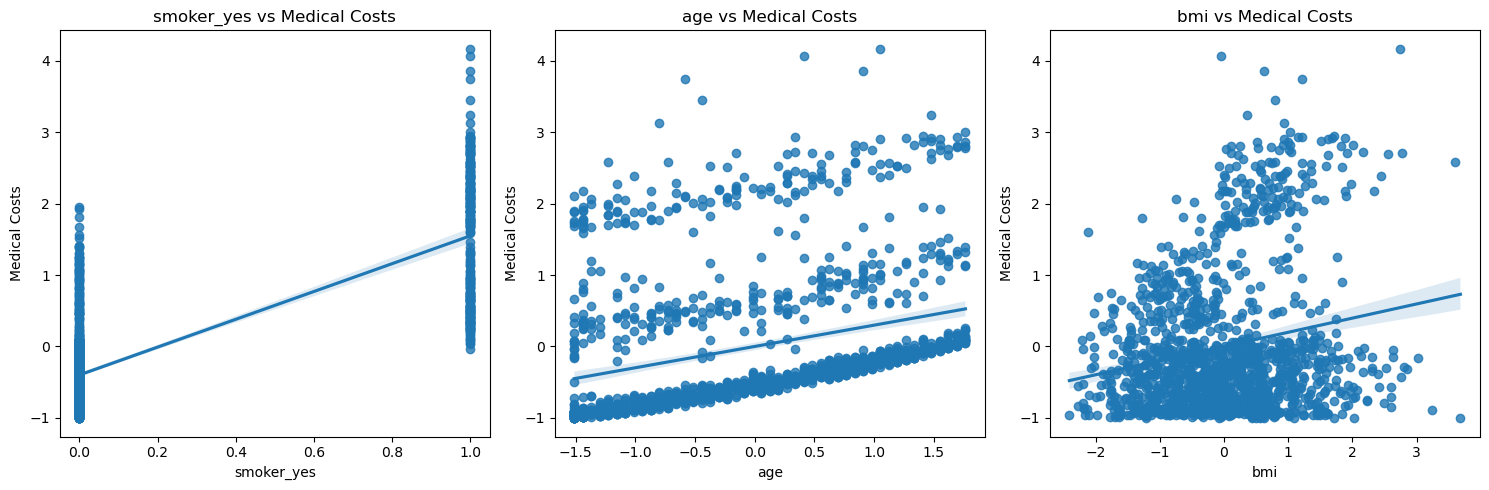

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the top three predictors
top_predictors = ['smoker_yes', 'age', 'bmi']

# Create scatter plots with regression lines for each top predictor
plt.figure(figsize=(15, 5))

for i, predictor in enumerate(top_predictors):
    plt.subplot(1, 3, i + 1)
    sns.regplot(x=predictor, y='medicalCost', data=dataset_encoded)
    plt.title(f'{predictor} vs Medical Costs')
    plt.xlabel(predictor)
    plt.ylabel('Medical Costs')

plt.tight_layout()
plt.show()


In [73]:
# now to build regression model

# Define the target variable
y = dataset_encoded['medicalCost']

# Build and evaluate linear regression models for each of the top three predictors
for predictor in top_predictors:
    X = sm.add_constant(dataset_encoded[predictor])
    model = sm.OLS(y, X).fit()
    print(f"\nLinear Regression Model for {predictor}:")
    print(model.summary())



Linear Regression Model for smoker_yes:
                            OLS Regression Results                            
Dep. Variable:            medicalCost   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     2176.
Date:                Tue, 04 Jun 2024   Prob (F-statistic):          1.41e-282
Time:                        14:35:48   Log-Likelihood:                -1250.8
No. Observations:                1337   AIC:                             2506.
Df Residuals:                    1335   BIC:                             2516.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

In [74]:
import statsmodels.api as sm

# Define the target variable
y = dataset_encoded['medicalCost']

# Build and evaluate linear regression models for each of the top three predictors
for predictor in top_predictors:
    X = sm.add_constant(dataset_encoded[predictor])  # Add a constant term for the intercept
    model = sm.OLS(y, X).fit()  # Fit the model
    print(f"\nLinear Regression Model for {predictor}:")
    print(model.summary())  # Print the summary



Linear Regression Model for smoker_yes:
                            OLS Regression Results                            
Dep. Variable:            medicalCost   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     2176.
Date:                Tue, 04 Jun 2024   Prob (F-statistic):          1.41e-282
Time:                        14:40:38   Log-Likelihood:                -1250.8
No. Observations:                1337   AIC:                             2506.
Df Residuals:                    1335   BIC:                             2516.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

In [75]:
# the next step is to now evaluate the performance of the models
# and i can do this by building mutivariate regression models with the top 3

# Define the features (top 3 predictors)
X_top3 = dataset_encoded[top_predictors]

# Add a constant term for the intercept
X_top3 = sm.add_constant(X_top3)

# Build the multivariate regression model
model_top3 = sm.OLS(y, X_top3).fit()

# Display the model summary
print("\nMultivariate Regression Model with Top 3 Predictors:")
print(model_top3.summary())



Multivariate Regression Model with Top 3 Predictors:
                            OLS Regression Results                            
Dep. Variable:            medicalCost   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     1314.
Date:                Tue, 04 Jun 2024   Prob (F-statistic):               0.00
Time:                        14:46:15   Log-Likelihood:                -977.53
No. Observations:                1337   AIC:                             1963.
Df Residuals:                    1333   BIC:                             1984.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [76]:
# and a multivariate model with all the predictors and not just the top 3 

# Define the features (all predictors)
predictors_all = dataset_encoded_all.columns.drop('medicalCost')
X_all = dataset_encoded_all[predictors_all]

# Add a constant term for the intercept
X_all = sm.add_constant(X_all)

# Build the multivariate regression model
model_all = sm.OLS(y, X_all).fit()

# Display the model summary
print("\nMultivariate Regression Model with All Predictors:")
print(model_all.summary())



Multivariate Regression Model with All Predictors:
                            OLS Regression Results                            
Dep. Variable:            medicalCost   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     500.3
Date:                Tue, 04 Jun 2024   Prob (F-statistic):               0.00
Time:                        14:47:00   Log-Likelihood:                -666.95
No. Observations:                1337   AIC:                             1364.
Df Residuals:                    1322   BIC:                             1442.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [77]:
# and a multivariate model with all the predictors and not just the top 3 

# Define the features (all predictors)
predictors_all_2 = dataset_encoded.columns.drop('medicalCost')
X_all_2 = dataset_encoded[predictors_all_2]

# Add a constant term for the intercept
X_all_2 = sm.add_constant(X_all_2)

# Build the multivariate regression model
model_all_2 = sm.OLS(y, X_all_2).fit()

# Display the model summary
print("\nMultivariate Regression Model with All Predictors:")
print(model_all_2.summary())



Multivariate Regression Model with All Predictors:
                            OLS Regression Results                            
Dep. Variable:            medicalCost   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 04 Jun 2024   Prob (F-statistic):               0.00
Time:                        15:19:47   Log-Likelihood:                -968.38
No. Observations:                1337   AIC:                             1955.
Df Residuals:                    1328   BIC:                             2002.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------